# E-Commerce Content-Based Recommendation System

This notebook builds a **content-based recommender** for an e-commerce store using the `kz.csv` event-log dataset (an online electronics/appliances store).

**How content-based filtering works here:** instead of relying on other users' behavior (collaborative filtering), we describe every product with a "content profile" built from its **category hierarchy**, **brand**, and **price tier**. We turn that profile into a TF-IDF vector, then recommend products whose vectors are most *similar* (cosine similarity) to a product the shopper is currently viewing or has purchased — the classic "customers who liked this item might like these similar items" logic.

**Pipeline:**
1. Load & explore the raw event data
2. Build a clean, one-row-per-product catalog
3. Engineer text "content" features (category levels + brand + price tier)
4. Vectorize content with TF-IDF
5. Fit a Nearest Neighbors model using cosine distance
6. Write a `recommend()` function and demo it
7. Visualize the catalog (categories, brands, price)


## 1. Imports

Standard data-science stack: `numpy`/`pandas` for data wrangling, `matplotlib` for charts.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

`scikit-learn` tools for the recommender itself:
- `TfidfVectorizer` turns each product's text content into a weighted numeric vector.
- `cosine_similarity` measures how alike two vectors are (used for a small worked example).
- `NearestNeighbors` efficiently finds the top-N most similar products for any given product, which scales better than computing a full similarity matrix for large catalogs.

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors

## 2. Load the Dataset

`kz.csv` is a raw **event log**: each row is a purchase event (an item inside an order), not a unique product. Columns:
- `event_time` — timestamp of the purchase event
- `order_id` — order the event belongs to
- `product_id` — the product purchased
- `category_id` / `category_code` — product category, e.g. `electronics.smartphone`
- `brand` — manufacturer brand (has missing values)
- `price` — price paid
- `user_id` — the shopper

We'll load it and take a first look.

In [4]:
df = pd.read_csv('kz.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (434799, 8)


,event_time,order_id,product_id,category_id,category_code,brand,price,user_id
0,2020-04-24 11:50:39 UTC,2294359932054536986,1515966223509089906,2268105426648170900,electronics.tablet,samsung,162.01,1515915625441993984
1,2020-04-24 11:50:39 UTC,2294359932054536986,1515966223509089906,2268105426648170900,electronics.tablet,samsung,162.01,1515915625441993984
2,2020-04-24 14:37:43 UTC,2294444024058086220,2273948319057183658,2268105430162997728,electronics.audio.headphone,huawei,77.52,1515915625447879434
3,2020-04-24 14:37:43 UTC,2294444024058086220,2273948319057183658,2268105430162997728,electronics.audio.headphone,huawei,77.52,1515915625447879434
4,2020-04-26 08:45:57 UTC,2295716521449619559,1515966223509261697,2268105442636858090,furniture.kitchen.table,maestro,39.33,1515915625450382722


## 3. Explore the Data

Quick sanity checks: data types, missing values, and how many *unique* products/categories/brands we're actually working with (remember — the raw file has one row per purchase event, so the same product appears many times).

In [5]:
print(df.info())
print("\nMissing values:\n", df.isna().sum())
print(f"\nUnique products : {df['product_id'].nunique():,}")
print(f"Unique categories: {df['category_code'].nunique():,}")
print(f"Unique brands    : {df['brand'].nunique():,}")
print(f"Date range       : {df['event_time'].min()}  ->  {df['event_time'].max()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 434799 entries, 0 to 434798
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   event_time     434799 non-null  object 
 1   order_id       434799 non-null  int64  
 2   product_id     434799 non-null  int64  
 3   category_id    434799 non-null  int64  
 4   category_code  434799 non-null  object 
 5   brand          420718 non-null  object 
 6   price          434799 non-null  float64
 7   user_id        434799 non-null  int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 26.5+ MB
None

Missing values:
 event_time           0
order_id             0
product_id           0
category_id          0
category_code        0
brand            14081
price                0
user_id              0
dtype: int64

Unique products : 12,325
Unique categories: 123
Unique brands    : 570
Date range       : 1970-01-01 00:33:40 UTC  ->  2020-11-21 10:10:30 UTC


## 4. Build a Product Catalog

A content-based recommender needs **one row per product**, not per purchase event. We collapse the event log down to a product catalog by grouping on `product_id`, taking the (constant) category info, the most common brand, and the average price for each product.

We also fill missing brands with the label `"unknown"` so every product still has a usable text feature — dropping ~14k rows just because the brand is missing would throw away real products.

In [6]:
products = (
    df.groupby('product_id')
      .agg(
          category_id=('category_id', 'first'),
          category_code=('category_code', 'first'),
          brand=('brand', lambda s: s.mode().iat[0] if not s.mode().empty else 'unknown'),
          price=('price', 'mean'),
          n_purchases=('product_id', 'size'),
      )
      .reset_index()
)

products['brand'] = products['brand'].fillna('unknown').str.lower().str.strip()
products['price'] = products['price'].round(2)

print(f"Product catalog shape: {products.shape}")
products.head()

Product catalog shape: (12325, 6)


,product_id,category_id,category_code,brand,price,n_purchases
0,1515966223509088493,2268105428166508982,electronics.smartphone,apple,740.72,417
1,1515966223509088496,2268105458457772096,apparel.glove,xbox,266.18,161
2,1515966223509088497,2268105428166508982,electronics.smartphone,samsung,1215.25,424
3,1515966223509088498,2268105428166508982,electronics.smartphone,samsung,115.72,479
4,1515966223509088499,2268105407220155366,computers.notebook,lenovo,601.83,78


## 5. Feature Engineering: Building the "Content" Profile

This is the heart of a content-based recommender: turning each product's attributes into a short text description ("content soup") that captures what the product *is*.

- **Category hierarchy**: `category_code` looks like `electronics.smartphone` or `appliances.kitchen.refrigerators`. We split it into levels (`category_l1`, `category_l2`, `category_l3`) so the model can pick up on both broad department similarity (e.g. two products both in `electronics`) and fine-grained similarity (e.g. both `smartphone`s).
- **Brand**: repeated in the content string so it carries real TF-IDF weight (brand is often a strong similarity signal — customers viewing an Apple phone are often interested in other Apple products).
- **Price tier**: price itself isn't a text feature, so we bucket it into tiers (`budget`, `mid`, `premium`, `luxury`) using quantiles, and add the tier as a word — this nudges recommendations toward products in a similar price range.

In [7]:
def split_category(code):
    parts = str(code).split('.')
    parts += [parts[-1]] * (3 - len(parts))  # pad short codes by repeating the last level
    return parts[0], parts[1], parts[2]

products[['category_l1', 'category_l2', 'category_l3']] = products['category_code'].apply(
    lambda c: pd.Series(split_category(c))
)

products['price_tier'] = pd.qcut(
    products['price'], q=4, labels=['budget', 'mid', 'premium', 'luxury'], duplicates='drop'
)

# The "content soup": category levels + brand (weighted x2 for signal strength) + price tier
products['content'] = (
    products['category_l1'] + ' ' +
    products['category_l2'] + ' ' +
    products['category_l3'] + ' ' +
    (products['brand'] + ' ') * 2 +
    products['price_tier'].astype(str)
)

products[['product_id', 'category_code', 'brand', 'price', 'price_tier', 'content']].head(10)

,product_id,category_code,brand,price,price_tier,content
0,1515966223509088493,electronics.smartphone,apple,740.72,luxury,electronics smartphone smartphone apple apple ...
1,1515966223509088496,apparel.glove,xbox,266.18,premium,apparel glove glove xbox xbox premium
2,1515966223509088497,electronics.smartphone,samsung,1215.25,luxury,electronics smartphone smartphone samsung sams...
3,1515966223509088498,electronics.smartphone,samsung,115.72,premium,electronics smartphone smartphone samsung sams...
4,1515966223509088499,computers.notebook,lenovo,601.83,luxury,computers notebook notebook lenovo lenovo luxury
5,1515966223509088502,appliances.personal.hair_cutter,babyliss,71.74,mid,appliances personal hair_cutter babyliss babyl...
6,1515966223509088503,electronics.audio.headphone,delux,15.02,budget,electronics audio headphone delux delux budget
7,1515966223509088504,computers.peripherals.monitor,asus,559.49,luxury,computers peripherals monitor asus asus luxury
8,1515966223509088505,appliances.environment.vacuum,tefal,611.09,luxury,appliances environment vacuum tefal tefal luxury
9,1515966223509088506,electronics.audio.headphone,bloody,23.13,budget,electronics audio headphone bloody bloody budget


## 6. Vectorize Content with TF-IDF

`TfidfVectorizer` converts each product's `content` string into a sparse numeric vector. Words that are common across most products (e.g. a very generic top-level category) get down-weighted, while distinctive, product-specific words (a rare brand, a specific sub-category) get up-weighted — this is exactly what makes cosine similarity between two vectors a good proxy for "how similar are these two products".

In [8]:
tfidf = TfidfVectorizer(token_pattern=r"[a-zA-Z0-9]+")
tfidf_matrix = tfidf.fit_transform(products['content'])

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}  (products x vocabulary)")
print(f"Vocabulary size: {len(tfidf.vocabulary_)}")

TF-IDF matrix shape: (12325, 742)  (products x vocabulary)
Vocabulary size: 742


## 7. Worked Example: Cosine Similarity

Before scaling up, let's sanity-check the idea on a small sample using `cosine_similarity` directly: compare the first 5 products to each other and see that products sharing category/brand/price-tier score higher.

In [9]:
sample = products.head(5)
sample_sim = cosine_similarity(tfidf_matrix[:5])

sim_df = pd.DataFrame(
    sample_sim,
    index=sample['category_code'] + " | " + sample['brand'],
    columns=sample['category_code'] + " | " + sample['brand'],
)
sim_df.round(2)

,electronics.smartphone | apple,apparel.glove | xbox,electronics.smartphone | samsung,electronics.smartphone | samsung,computers.notebook | lenovo
electronics.smartphone | apple,1.00,0.00,0.54,0.50,0.03
apparel.glove | xbox,0.00,1.00,0.00,0.02,0.00
electronics.smartphone | samsung,0.54,0.00,1.00,0.96,0.04
electronics.smartphone | samsung,0.50,0.02,0.96,1.00,0.00
computers.notebook | lenovo,0.03,0.00,0.04,0.00,1.00


## 8. Fit a Nearest Neighbors Model

Computing a full cosine-similarity matrix for every pair of products (12k x 12k) works but wastes memory and doesn't scale to a real catalog. `NearestNeighbors` with `metric='cosine'` finds only the top-N closest products for any query product on demand, which is the practical approach for production-sized catalogs.

In [10]:
nn_model = NearestNeighbors(metric='cosine', algorithm='brute')
nn_model.fit(tfidf_matrix)

# Fast lookup from product_id -> row index in the products/tfidf_matrix table
product_index = pd.Series(products.index, index=products['product_id'])

print("Model fitted on", tfidf_matrix.shape[0], "products.")

Model fitted on 12325 products.


## 9. The `recommend()` Function

Given a `product_id`, this:
1. Looks up its row in the TF-IDF matrix
2. Asks the fitted `NearestNeighbors` model for the `top_n + 1` closest products (cosine distance)
3. Drops the product itself from the results
4. Returns a tidy DataFrame of recommended products with a `similarity` score (`1 - distance`)

In [11]:
def recommend(product_id, top_n=10):
    if product_id not in product_index:
        raise ValueError(f"product_id {product_id} not found in catalog")

    idx = product_index[product_id]
    distances, indices = nn_model.kneighbors(tfidf_matrix[idx], n_neighbors=top_n + 1)

    result = products.iloc[indices[0]].copy()
    result['similarity'] = 1 - distances[0]
    result = result[result['product_id'] != product_id]  # exclude the query product itself

    cols = ['product_id', 'category_code', 'brand', 'price', 'price_tier', 'similarity']
    return result[cols].reset_index(drop=True)

## 10. Demo: Recommend Similar Products

Let's pick a real product from the catalog (a smartphone, for a clear example) and see what the recommender suggests.

In [12]:
# Pick an example product to query (a smartphone) - falls back to a random product if none found
smartphone_rows = products[products['category_code'].str.contains('smartphone', na=False)]
query_id = smartphone_rows['product_id'].iloc[0] if not smartphone_rows.empty else products['product_id'].sample(1, random_state=42).iloc[0]

query_product = products[products['product_id'] == query_id][['product_id', 'category_code', 'brand', 'price', 'price_tier']]
print("Query product:")
display(query_product)

print("\nTop 10 recommended products:")
recommend(query_id, top_n=10)

Query product:


,product_id,category_code,brand,price,price_tier
0,1515966223509088493,electronics.smartphone,apple,740.72,luxury



Top 10 recommended products:


,product_id,category_code,brand,price,price_tier,similarity
0,1515966223509107040,electronics.smartphone,apple,693.96,luxury,1.0
1,1515966223509105987,electronics.smartphone,apple,485.86,luxury,1.0
2,1515966223509117476,electronics.smartphone,apple,833.08,luxury,1.0
3,1515966223509117174,electronics.smartphone,apple,1618.73,luxury,1.0
4,1515966223509117070,electronics.smartphone,apple,485.86,luxury,1.0
5,1515966223509115692,electronics.smartphone,apple,462.71,luxury,1.0
6,1515966223509107930,electronics.smartphone,apple,925.67,luxury,1.0
7,1515966223509118503,electronics.smartphone,apple,463.17,luxury,1.0
8,1515966223509105111,electronics.smartphone,apple,1387.01,luxury,1.0
9,1515966223509105032,electronics.smartphone,apple,1317.80,luxury,1.0


Let's try a second example from a completely different category to confirm recommendations stay relevant to that product's own category/brand/price niche.

In [13]:
other_rows = products[products['category_code'].str.startswith('appliances', na=False)]
query_id_2 = other_rows['product_id'].iloc[0] if not other_rows.empty else products['product_id'].sample(1, random_state=7).iloc[0]

query_product_2 = products[products['product_id'] == query_id_2][['product_id', 'category_code', 'brand', 'price', 'price_tier']]
print("Query product:")
display(query_product_2)

print("\nTop 10 recommended products:")
recommend(query_id_2, top_n=10)

Query product:


,product_id,category_code,brand,price,price_tier
5,1515966223509088502,appliances.personal.hair_cutter,babyliss,71.74,mid



Top 10 recommended products:


,product_id,category_code,brand,price,price_tier,similarity
0,1515966223509104775,appliances.personal.hair_cutter,babyliss,97.20,mid,1.000000
1,1515966223509089916,appliances.personal.hair_cutter,babyliss,30.07,mid,1.000000
2,1515966223509258429,appliances.personal.hair_cutter,babyliss,92.57,mid,1.000000
3,1515966223509089888,appliances.personal.hair_cutter,babyliss,37.01,mid,1.000000
4,1515966223509105019,appliances.personal.hair_cutter,babyliss,90.25,mid,1.000000
5,2309018264182718765,appliances.personal.hair_cutter,babyliss,27.75,budget,0.982512
6,1515966223509122452,appliances.personal.hair_cutter,babyliss,27.75,budget,0.982512
7,2273948189973282883,appliances.personal.hair_cutter,babyliss,27.75,budget,0.982512
8,1515966223509235762,appliances.personal.massager,babyliss,41.64,mid,0.811592
9,1515966223509336051,appliances.personal.massager,babyliss,48.59,mid,0.811592


## 11. Visualize the Catalog

A few quick charts to sanity-check the data the recommender is built on: the price distribution (and where the tier cutoffs fall), the most common top-level categories, and the most common brands.

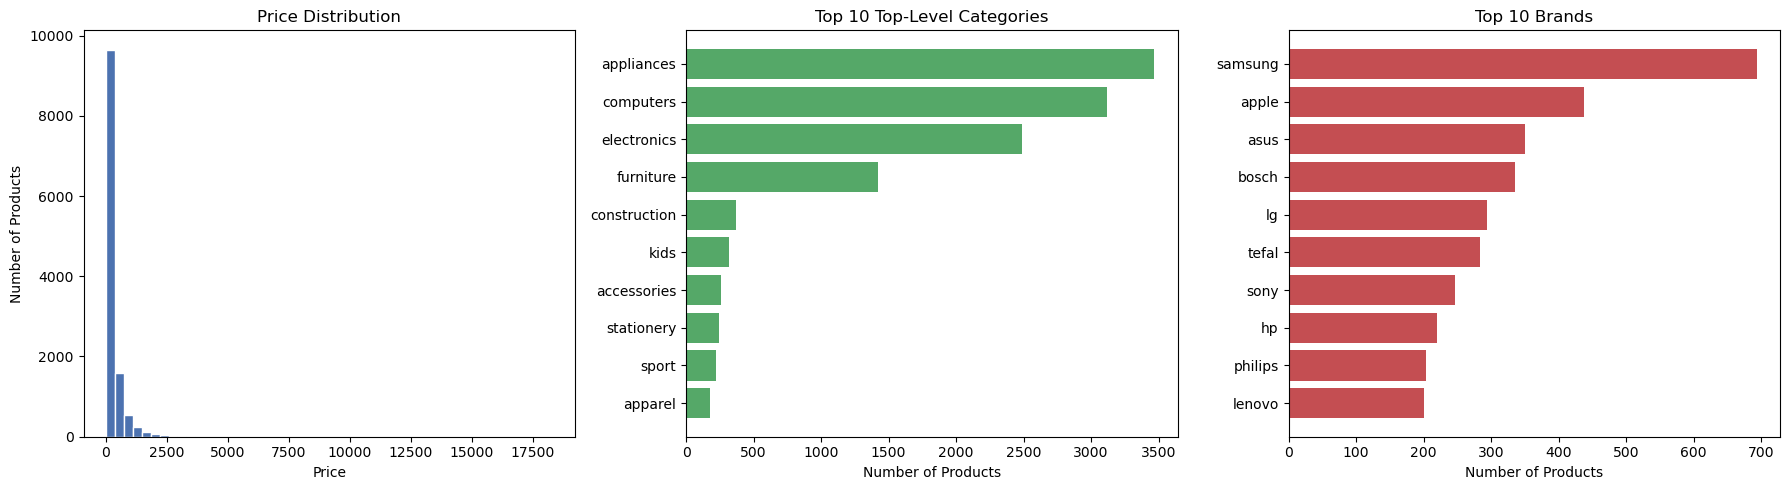

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Price distribution with tier boundaries
axes[0].hist(products['price'], bins=50, color='#4C72B0', edgecolor='white')
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Number of Products')

# Top categories
top_categories = products['category_l1'].value_counts().head(10)
axes[1].barh(top_categories.index[::-1], top_categories.values[::-1], color='#55A868')
axes[1].set_title('Top 10 Top-Level Categories')
axes[1].set_xlabel('Number of Products')

# Top brands
top_brands = products[products['brand'] != 'unknown']['brand'].value_counts().head(10)
axes[2].barh(top_brands.index[::-1], top_brands.values[::-1], color='#C44E52')
axes[2].set_title('Top 10 Brands')
axes[2].set_xlabel('Number of Products')

plt.tight_layout()
plt.show()

## 12. Summary

We built an end-to-end **content-based recommendation system**:

- Collapsed raw purchase events into a **one-row-per-product catalog**.
- Engineered a text "content profile" per product from its **category hierarchy**, **brand**, and **price tier**.
- Vectorized that content with **TF-IDF** and used **cosine similarity / Nearest Neighbors** to find products with the most similar profiles.
- Wrapped it in a reusable `recommend(product_id, top_n)` function, ready to plug into a product page ("customers also liked...") or an email campaign.

**Possible next steps:** blend in product titles/descriptions if available (richer TF-IDF vocabulary), weight the price-tier or brand terms differently, combine with a collaborative-filtering model for a hybrid recommender, or add an evaluation step (e.g. holding out purchases and checking recall@k).